# Assignment 1 Part C and D

This notebook trains a PyTorch MNIST model on CUDA when available, plots loss and accuracy per epoch, and shows 10 test images with predicted classes.

It now includes runs for 5, 10, and 20 epochs. Keep in mind it is running sequantially so taking some time

Rembember! Choose the venv python kernel when running

In [3]:
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt

from C import run_experiment

In [4]:
epoch_settings = [5, 10, 20]
results = {}

for epochs in epoch_settings:
    print(f'Running experiment with {epochs} epochs...')
    model, history, loss_curve_path, accuracy_curve_path, test_predictions_path = run_experiment(
        batch_size=64,
        epochs=epochs,
        learning_rate=0.001,
        output_dir=f'outputs/epochs_{epochs}',
    )
    results[epochs] = {
        'history': history,
        'loss_curve_path': Path(loss_curve_path),
        'accuracy_curve_path': Path(accuracy_curve_path),
        'test_predictions_path': Path(test_predictions_path),
    }

Running experiment with 5 epochs...
Using CUDA GPU 0: NVIDIA GeForce RTX 5060 Ti (CUDA 12.8)
Train batches: 844
Validation batches: 94
Test batches:  157
Model device:  cuda:0
Epoch 01/5 | train_loss=0.4008 | train_acc=88.17% | val_loss=0.2303 | val_acc=93.27% | test_loss=0.2107 | test_acc=93.75%
Saved new best model to: C:\Users\emil_\vscode\Assignment1\part_1\C_D\outputs\epochs_5\best_model.pt
Epoch 02/5 | train_loss=0.1835 | train_acc=94.36% | val_loss=0.1678 | val_acc=95.03% | test_loss=0.1490 | test_acc=95.58%
Saved new best model to: C:\Users\emil_\vscode\Assignment1\part_1\C_D\outputs\epochs_5\best_model.pt
Epoch 03/5 | train_loss=0.1345 | train_acc=95.85% | val_loss=0.1440 | val_acc=95.53% | test_loss=0.1270 | test_acc=95.95%
Saved new best model to: C:\Users\emil_\vscode\Assignment1\part_1\C_D\outputs\epochs_5\best_model.pt
Epoch 04/5 | train_loss=0.1071 | train_acc=96.65% | val_loss=0.1333 | val_acc=96.22% | test_loss=0.1219 | test_acc=96.24%
Saved new best model to: C:\Users

In [5]:
for epochs in epoch_settings:
    history = results[epochs]['history']
    print(
        f"{epochs} epochs -> "
        f"final train loss: {history['train_loss'][-1]:.4f}, "
        f"final train acc: {history['train_accuracy'][-1]:.2%}, "
        f"final val acc: {history['val_accuracy'][-1]:.2%}, "
        f"final test loss: {history['test_loss'][-1]:.4f}, "
        f"final test acc: {history['test_accuracy'][-1]:.2%}"
    )

5 epochs -> final train loss: 0.0896, final train acc: 97.16%, final val acc: 96.68%, final test loss: 0.0972, final test acc: 97.02%
10 epochs -> final train loss: 0.0519, final train acc: 98.32%, final val acc: 97.03%, final test loss: 0.0982, final test acc: 97.22%
20 epochs -> final train loss: 0.0290, final train acc: 98.96%, final val acc: 97.28%, final test loss: 0.1081, final test acc: 97.44%


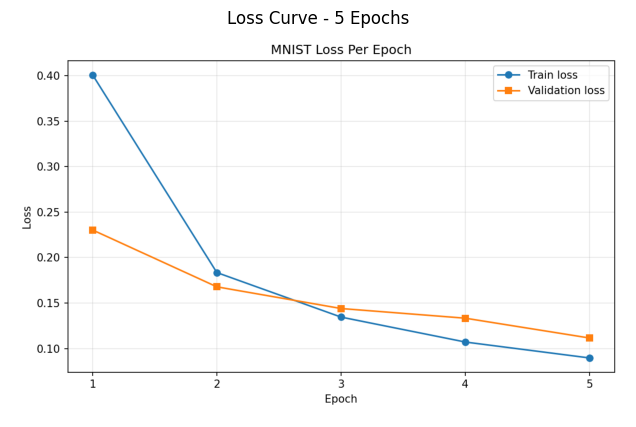

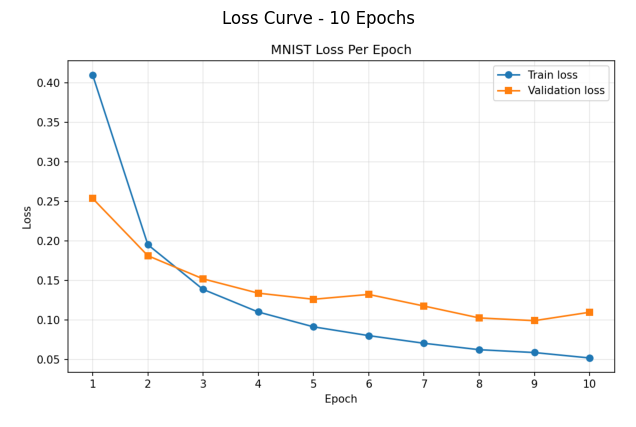

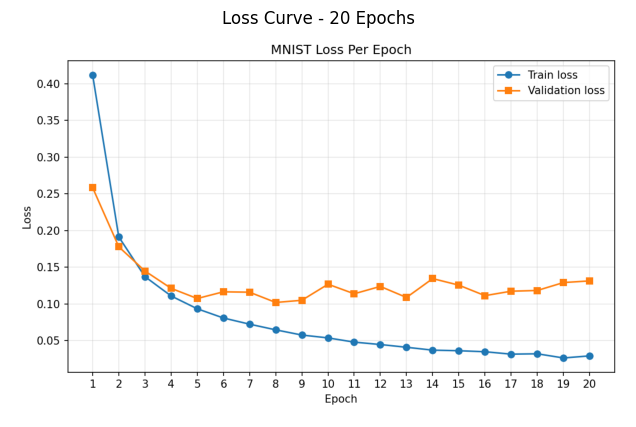

In [6]:
for epochs in epoch_settings:
    loss_image = mpimg.imread(results[epochs]['loss_curve_path'])
    plt.figure(figsize=(9, 5))
    plt.imshow(loss_image)
    plt.axis('off')
    plt.title(f'Loss Curve - {epochs} Epochs')
    plt.show()

Conclusion: 
If we look at the above and below curves we can see that ~10 epochs is sufficent for our models. Some tendency to overfitting is seen when train loss is decreased but validation loss remains the same.

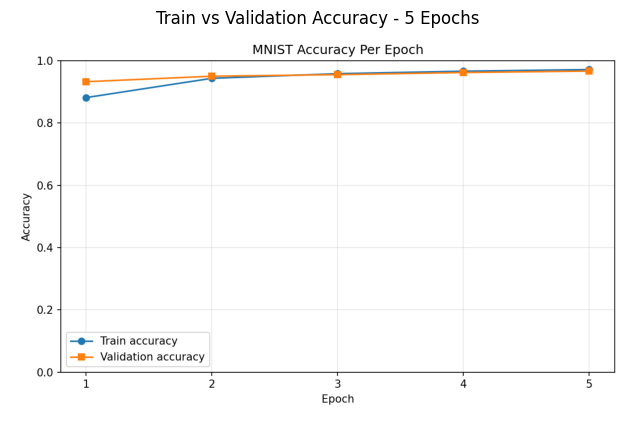

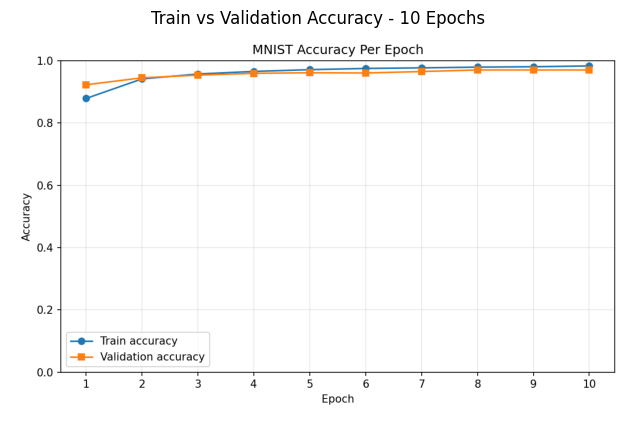

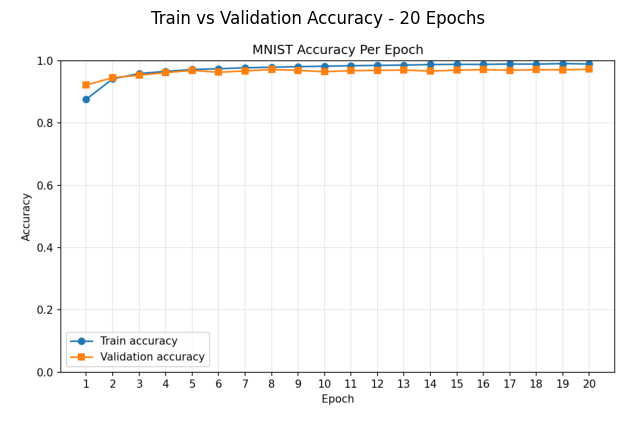

In [7]:
for epochs in epoch_settings:
    accuracy_image = mpimg.imread(results[epochs]['accuracy_curve_path'])
    plt.figure(figsize=(9, 5))
    plt.imshow(accuracy_image)
    plt.axis('off')
    plt.title(f'Train vs Validation Accuracy - {epochs} Epochs')
    plt.show()

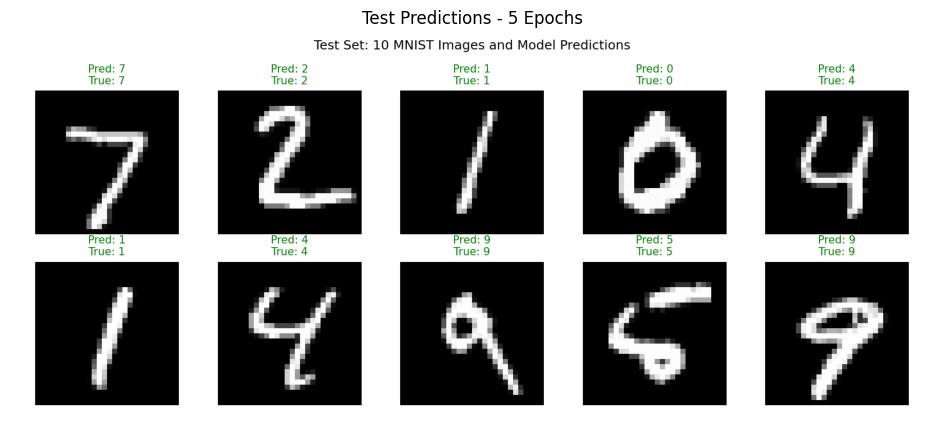

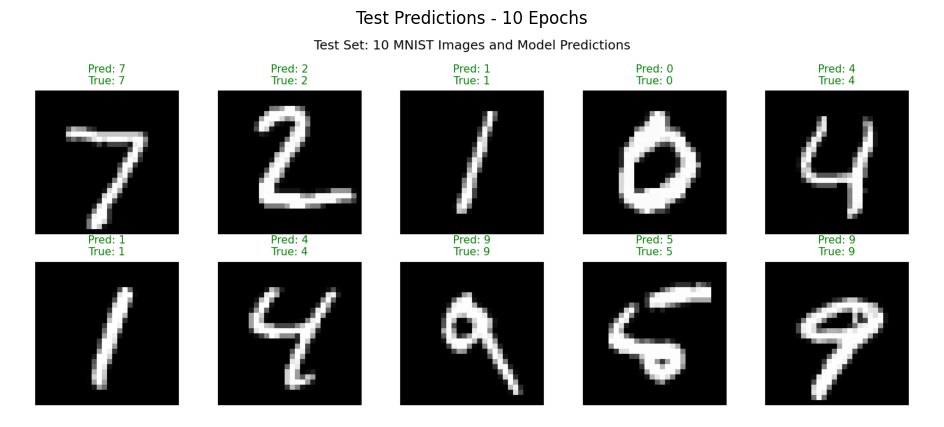

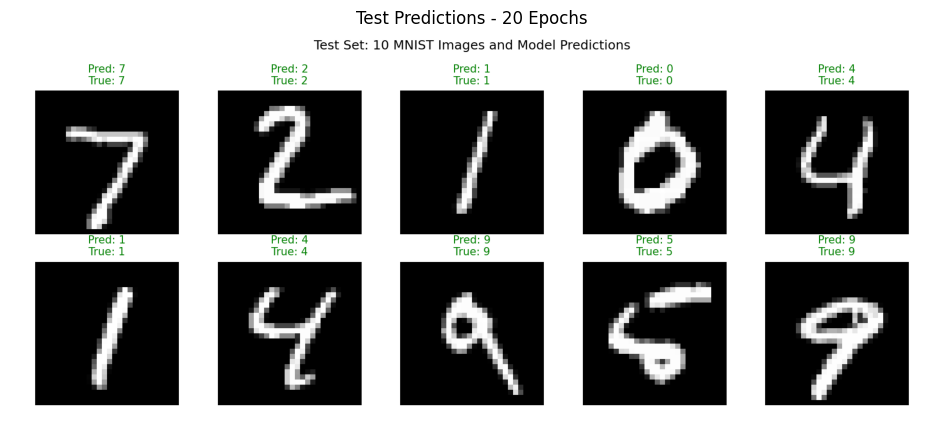

In [8]:
for epochs in epoch_settings:
    test_predictions_image = mpimg.imread(results[epochs]['test_predictions_path'])
    plt.figure(figsize=(12, 5))
    plt.imshow(test_predictions_image)
    plt.axis('off')
    plt.title(f'Test Predictions - {epochs} Epochs')
    plt.show()